In [2]:
!pip install earthengine-api geemap -q

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='ee-kirschenworks')

In [3]:
adm1 = ee.FeatureCollection("FAO/GAUL/2015/level1")

aoi = (adm1
       .filter(ee.Filter.eq("ADM0_NAME", "Thailand"))
       .filter(ee.Filter.eq("ADM1_NAME", "Chanthaburi"))
       .geometry())

points = ee.FeatureCollection.randomPoints(region=aoi, points=30, seed=42)

Map = geemap.Map(center=[12.8, 102.1], zoom=9)
Map.addLayer(aoi, {}, "Chanthaburi AOI")
Map.addLayer(points, {"color": "yellow"}, "Sample points")
Map

Map(center=[12.8, 102.1], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [4]:
S2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")

# ช่วงแล้ง: Jan 1 - Mar 31
def date_range(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 3, 31)
    return start, end

def mask_s2_sr(img):
    scl = img.select("SCL")
    qa  = img.select("QA60")

    scl_mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))

    cloud_bit  = 1 << 10
    cirrus_bit = 1 << 11
    qa_mask = qa.bitwiseAnd(cloud_bit).eq(0).And(qa.bitwiseAnd(cirrus_bit).eq(0))

    return (img.updateMask(scl_mask.And(qa_mask))
              .divide(10000)  # scale reflectance
              .copyProperties(img, img.propertyNames()))

def composite(year):
    start, end = date_range(year)
    col = (S2.filterBounds(aoi)
             .filterDate(start, end)
             .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", 60))
             .map(mask_s2_sr))
    return col.median().clip(aoi)

img2020 = composite(2020)
img2022 = composite(2022)
img2024 = composite(2024)

def show_metadata(img, label):
    info = {
        "label": label,
        "bands": img.bandNames().getInfo(),
        "projection(B4)": img.select("B4").projection().getInfo(),  # red band projection
        "nominalScale(B4_m)": img.select("B4").projection().nominalScale().getInfo(),
    }
    return info

meta = pd.DataFrame([
    show_metadata(img2020, "S2 composite 2020-01..03"),
    show_metadata(img2022, "S2 composite 2022-01..03"),
    show_metadata(img2024, "S2 composite 2024-01..03"),
])

meta

,label,bands,projection(B4),nominalScale(B4_m)
0,S2 composite 2020-01..03,"[B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11,...","{'type': 'Projection', 'crs': 'EPSG:4326', 'tr...",111319.490793
1,S2 composite 2022-01..03,"[B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11,...","{'type': 'Projection', 'crs': 'EPSG:4326', 'tr...",111319.490793
2,S2 composite 2024-01..03,"[B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11,...","{'type': 'Projection', 'crs': 'EPSG:4326', 'tr...",111319.490793


In [25]:
Map = geemap.Map(center=[12.8, 102.1], zoom=9)

In [26]:
def ndvi(img):
    return img.normalizedDifference(["B8", "B4"]).rename("NDVI")

ndvi2020 = ndvi(img2020)
ndvi2022 = ndvi(img2022)
ndvi2024 = ndvi(img2024)

vis_ndvi = {
"min": -0.2,
"max": 0.9,
"palette": ["#2c105c","#711f81","#b63679","#ee605e","#ffa600","#d9ef8b","#1a9850"]
}

Map.addLayer(aoi, {"color":"black"}, "AOI")
Map.addLayer(ndvi2020, vis_ndvi, "NDVI 2020")
Map.addLayer(ndvi2022, vis_ndvi, "NDVI 2022")
Map.addLayer(ndvi2024, vis_ndvi, "NDVI 2024")

legend_ndvi = {
"-0.2 – 0 (Water / Built-up)": "#2c105c",
"0 – 0.1 (Very low vegetation)": "#711f81",
"0.1 – 0.2 (Bare soil)": "#b63679",
"0.2 – 0.3 (Low vegetation)": "#ee605e",
"0.3 – 0.5 (Moderate vegetation)": "#ffa600",
"0.5 – 0.7 (Dense vegetation)": "#d9ef8b",
"0.7 – 0.9 (Very dense vegetation)": "#1a9850"
}

Map.add_legend(title="NDVI Legend", legend_dict=legend_ndvi, position="bottomleft")

Map

Map(center=[12.8, 102.1], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [27]:
d2020_2022 = ndvi2022.subtract(ndvi2020).rename("dNDVI_20_22")
d2022_2024 = ndvi2024.subtract(ndvi2022).rename("dNDVI_22_24")
d2020_2024 = ndvi2024.subtract(ndvi2020).rename("dNDVI_20_24")

# Threshold
thr = 0.15
loss_22_24 = d2022_2024.lte(-thr).selfMask()   # NDVI ลด
gain_22_24 = d2022_2024.gte(thr).selfMask()    # NDVI เพิ่ม

# Visualization for ΔNDVI
vis_d = {
    "min": -0.5,
    "max": 0.5,
    "palette": ["#d73027", "#f46d43", "#fdae61", "#ffffbf", "#a6d96a", "#1a9850"]
}

aoi_outline = ee.Image().byte().paint(aoi, 1, 2)  # width=2 px
vis_aoi = {"palette": ["000000"], "opacity": 0.9}

Map = geemap.Map(center=[12.8, 102.1], zoom=9)

Map.addLayer(d2020_2022, vis_d, "ΔNDVI 2020→2022")
Map.addLayer(d2022_2024, vis_d, "ΔNDVI 2022→2024")
Map.addLayer(loss_22_24, {"palette": ["#d73027"]}, f"LOSS (<= -{thr})")
Map.addLayer(gain_22_24, {"palette": ["#1a9850"]}, f"GAIN (>= +{thr})")
Map.addLayer(aoi_outline, vis_aoi, "AOI (outline)")

legend_dndvi = {
    "< -0.3 (Decrease strong)": "#d73027",
    "-0.3 to -0.15 (Decrease)": "#f46d43",
    "-0.15 to -0.05 (Slight decrease)": "#fdae61",
    "-0.05 to 0.05 (No change)": "#ffffbf",
    "0.05 to 0.15 (Slight increase)": "#a6d96a",
    "> 0.15 (Increase strong)": "#1a9850",
}
Map.add_legend(title="ΔNDVI Legend (Change)", legend_dict=legend_dndvi)

legend_lg = {
    f"LOSS (ΔNDVI <= -{thr})": "#d73027",
    f"GAIN (ΔNDVI >= +{thr})": "#1a9850",
}
Map.add_legend(title="Significant Change", legend_dict=legend_lg)

Map

Map(center=[12.8, 102.1], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

({'area': 572.4558259343933}, {'area': 208.70227234972512})

In [8]:
dem = ee.Image("USGS/SRTMGL1_003").select("elevation").clip(aoi)

# แบ่งชั้นความสูง (เมตร)
bins = ee.List.sequence(0, 1000, 100)

def bin_elev(dem_img):
    b = dem_img.divide(100).floor().toInt().rename("bin")
    b = b.where(b.gt(10), 10)
    return b

elev_bin = bin_elev(dem)

stack = ndvi2024.addBands(elev_bin)

group_stats = stack.reduceRegion(
    reducer=ee.Reducer.mean().group(groupField=1, groupName="bin"),
    geometry=aoi,
    scale=30,
    maxPixels=1e13
)

groups = group_stats.get("groups").getInfo()
df = pd.DataFrame(groups)
df["elev_range_m"] = df["bin"].apply(lambda b: f"{b*100}-{b*100+100}" if b < 10 else "1000+")
df = df[["elev_range_m", "mean"]].rename(columns={"mean":"mean_NDVI_2024"})
df

,elev_range_m,mean_NDVI_2024
0,-100-0,0.254786
1,0-100,0.542967
2,100-200,0.618015
3,200-300,0.648987
4,300-400,0.776305
5,400-500,0.810865
6,500-600,0.821165
7,600-700,0.830730
8,700-800,0.836365
9,800-900,0.838611


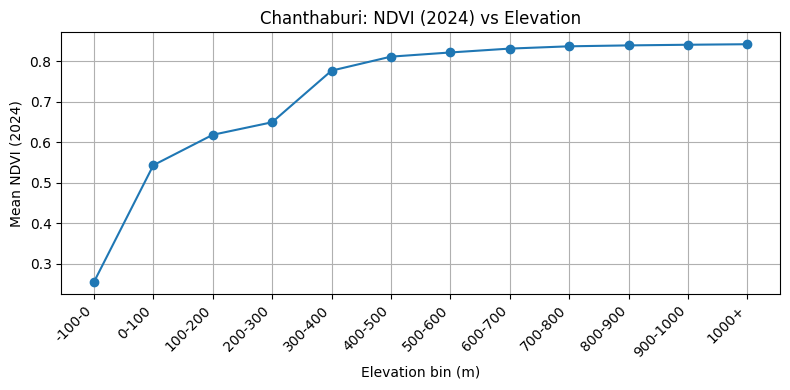

In [9]:
plt.figure(figsize=(8,4))
plt.plot(df["elev_range_m"], df["mean_NDVI_2024"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean NDVI (2024)")
plt.xlabel("Elevation bin (m)")
plt.title("Chanthaburi: NDVI (2024) vs Elevation")
plt.grid(True)
plt.tight_layout()
plt.show()

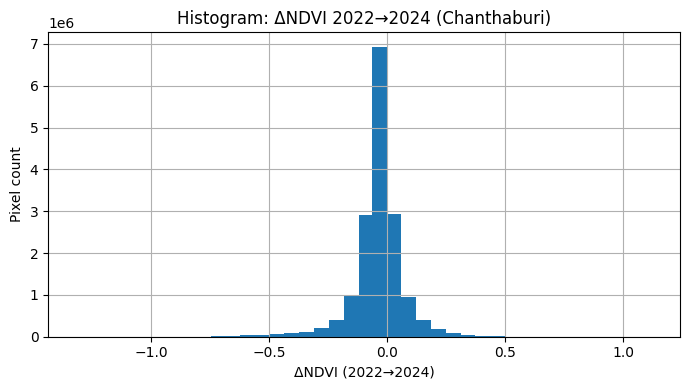

In [10]:
# Histogram ของ ΔNDVI 2022 ถึง 2024
hist = d2022_2024.reduceRegion(
    reducer=ee.Reducer.histogram(maxBuckets=60),
    geometry=aoi,
    scale=20,
    maxPixels=1e13
).getInfo()

h = hist["dNDVI_22_24"]
counts = np.array(h["histogram"])
bins = np.array(h["bucketMeans"])

plt.figure(figsize=(7,4))
plt.bar(bins, counts, width=(bins[1]-bins[0]))
plt.xlabel("ΔNDVI (2022→2024)")
plt.ylabel("Pixel count")
plt.title("Histogram: ΔNDVI 2022→2024 (Chanthaburi)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
def sample_points(ndvi_img, year_label):
    sampled = ndvi_img.sampleRegions(
        collection=points,
        scale=20,
        geometries=True
    ).map(lambda f: f.set("year", year_label))
    return sampled

sp = ee.FeatureCollection([
    sample_points(ndvi2020, 2020),
    sample_points(ndvi2022, 2022),
    sample_points(ndvi2024, 2024),
]).flatten()

# แปลงเป็น pandas
rows = sp.getInfo()["features"]
table = pd.DataFrame([{
    "year": r["properties"]["year"],
    "NDVI": r["properties"]["NDVI"],
    "lon": r["geometry"]["coordinates"][0],
    "lat": r["geometry"]["coordinates"][1],
} for r in rows])

table.head()

,year,NDVI,lon,lat
0,2020,0.764547,102.005048,12.988292
1,2020,0.683772,102.132070,12.969068
2,2020,0.496319,102.034692,12.614413
3,2020,0.513383,102.063618,12.857497
4,2020,0.451793,102.171596,13.270363


In [12]:
geemap.ee_export_image_to_drive(
    ndvi2024, description="NDVI_Chanthaburi_2024", folder="GEE_Lab3",
    region=aoi, scale=20, maxPixels=1e13
)

geemap.ee_export_image_to_drive(
    d2022_2024, description="dNDVI_Chanthaburi_2022_2024", folder="GEE_Lab3",
    region=aoi, scale=20, maxPixels=1e13
)